## Netflix Movies and TV Shows - Exploratory Data Analysis

1. Project Objective:

The objective of this project is to perform Exploratory Data Analysis (EDA) on the Netflix Movies & TV Shows dataset. The analysis focuses on understanding content distribution, data cleaning, handling missing values, feature engineering, visualization, and generating business insights using Python.

2. Import Libraries

In [88]:
import pandas as pd
import seaborn as sns


3. Load Dataset

In [89]:
df=pd.read_csv('netflix_titles.csv')

4. Create Working Copy

In [90]:
df_copy=df.copy()

5. Data Understanding
In this phase, we examine the dataset's structure, data types, dimensions, and summary statistics to understand the data before cleaning and analysis.

In [91]:
df_copy.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [92]:
df_copy.shape

(8807, 12)

In [93]:
df_copy.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [94]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [95]:
df_copy.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

In [96]:
df_copy.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


6. Data Cleaning
This phase identifies missing values, duplicate records, and data quality issues to ensure the dataset is reliable for analysis.

In [97]:
df_copy.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [98]:
missing_summary=(df_copy.isnull().sum() / len(df_copy)) * 100
missing_summary

show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       0.113546
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64

In [99]:
df_copy.duplicated().sum()

np.int64(0)

In [100]:
# Check the number of unique values in each column
df_copy.nunique()

show_id         8807
type               2
title           8807
director        4528
cast            7692
country          748
date_added      1767
release_year      74
rating            17
duration         220
listed_in        514
description     8775
dtype: int64

7. Univariate Analysis
Univariate analysis focuses on examining one variable at a time to understand its distribution, frequency, and key characteristics.

In [101]:
#count unique value in specific column
df_copy['type'].nunique()

2

In [102]:
#count frequency of each category
df_copy['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [103]:
df_copy['rating'].value_counts()


rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

In [104]:
df_copy['release_year'].describe()

count    8807.000000
mean     2014.180198
std         8.819312
min      1925.000000
25%      2013.000000
50%      2017.000000
75%      2019.000000
max      2021.000000
Name: release_year, dtype: float64

In [105]:
df_copy['release_year'].value_counts()

release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
        ... 
1959       1
1925       1
1961       1
1947       1
1966       1
Name: count, Length: 74, dtype: int64

In [106]:
df_copy['release_year'].mean() #shows average release year

np.float64(2014.1801975701146)

In [107]:
df_copy['release_year'].median()

2017.0

In [108]:
df_copy['release_year'].mode() #most frequently occurring year

0    2018
Name: release_year, dtype: int64

Text(0, 0.5, 'Number of Titles')

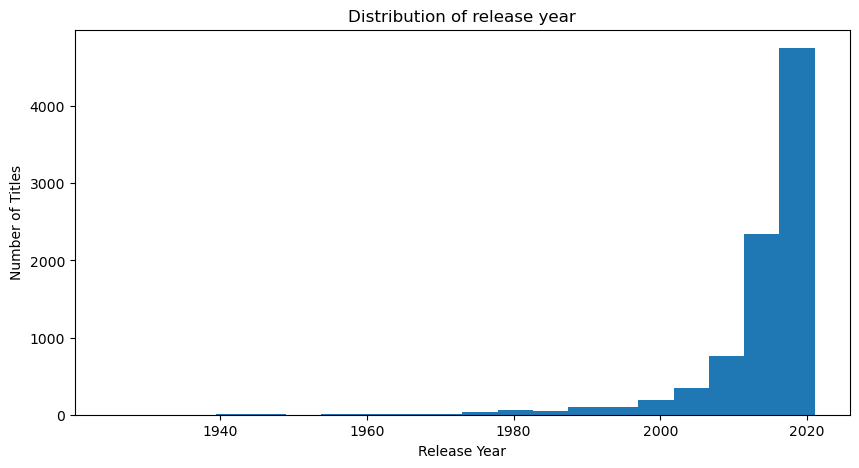

In [109]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.hist(df_copy['release_year'], bins=20)

plt.title('Distribution of release year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')

Text(0.5, 0, 'Year')

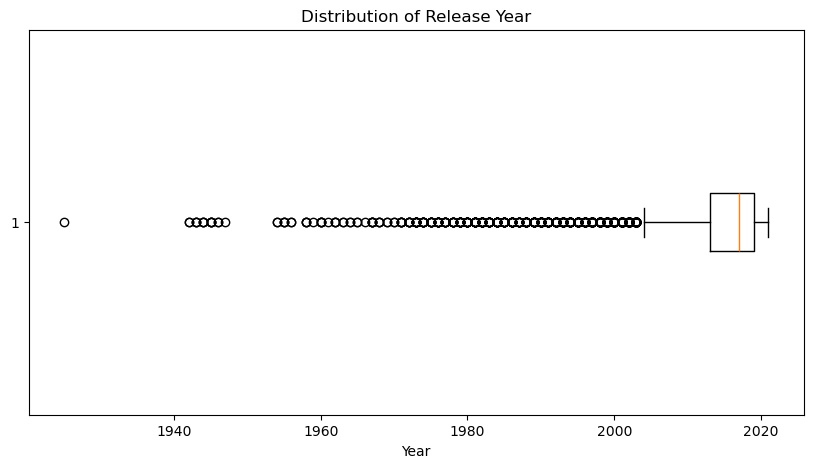

In [110]:
plt.figure(figsize=(10,5))
plt.boxplot(df_copy['release_year'], vert=False)
plt.title('Distribution of Release Year')
plt.xlabel('Year')

In [111]:
df_copy['type'].unique()

array(['Movie', 'TV Show'], dtype=object)

In [112]:
(df_copy['type'].value_counts(normalize=True) * 100).round(2)

type
Movie      69.62
TV Show    30.38
Name: proportion, dtype: float64

Text(0, 0.5, 'Count')

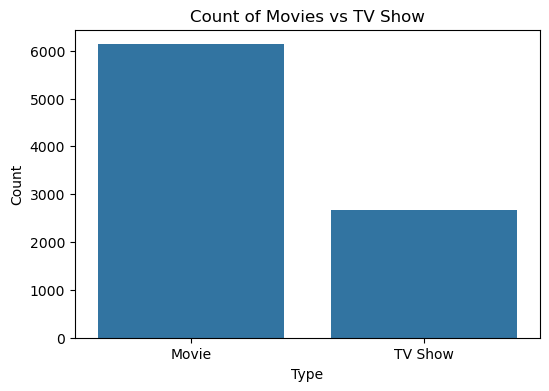

In [113]:
import seaborn as sns
plt.figure(figsize=(6,4))
sns.countplot(data=df_copy, x='type')
plt.title('Count of Movies vs TV Show')
plt.xlabel('Type')
plt.ylabel('Count')


### Observation:
 1. Movies make up the majority of Netflix's content library than TV Shows.

In [114]:
df_copy['rating'].unique()

array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', '74 min', '84 min', '66 min', 'NR', nan,
       'TV-Y7-FV', 'UR'], dtype=object)

In [115]:
df_copy['rating'].nunique()

17

In [116]:
df_copy['rating'].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

In [117]:
(df_copy['rating'].value_counts(normalize=True) *100).round(2)

rating
TV-MA       36.43
TV-14       24.54
TV-PG        9.80
R            9.08
PG-13        5.57
TV-Y7        3.79
TV-Y         3.49
PG           3.26
TV-G         2.50
NR           0.91
G            0.47
TV-Y7-FV     0.07
NC-17        0.03
UR           0.03
74 min       0.01
84 min       0.01
66 min       0.01
Name: proportion, dtype: float64

Text(0, 0.5, 'Count')

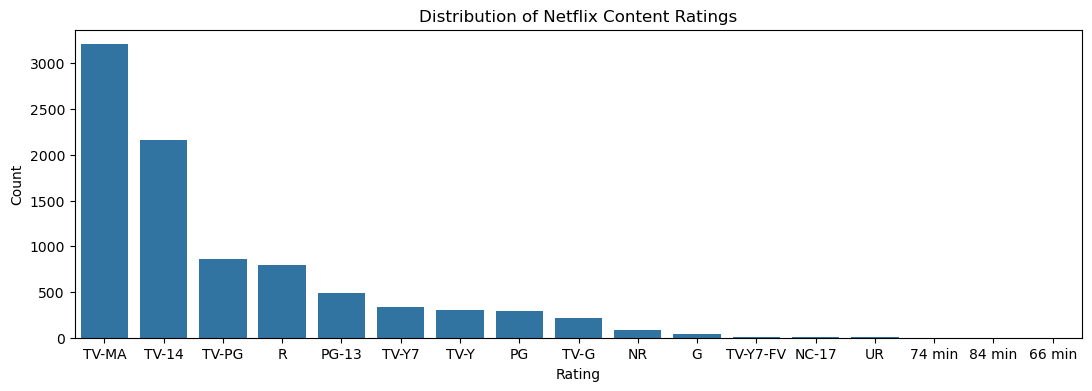

In [118]:
plt.figure(figsize=(13,4))
sns.countplot(data=df_copy, x='rating',
              order=df_copy['rating'].value_counts().index)
plt.title('Distribution of Netflix Content Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')

### Observation:
1. TV-MA is the most common rating.
2. Most Netflix content is targeted toward mature audiences.

In [119]:
df_copy['country'].nunique()

748

In [120]:
df_copy['country'].value_counts()

country
United States                             2818
India                                      972
United Kingdom                             419
Japan                                      245
South Korea                                199
                                          ... 
Romania, Bulgaria, Hungary                   1
Uruguay, Guatemala                           1
France, Senegal, Belgium                     1
Mexico, United States, Spain, Colombia       1
United Arab Emirates, Jordan                 1
Name: count, Length: 748, dtype: int64

Text(0, 0.5, 'Count')

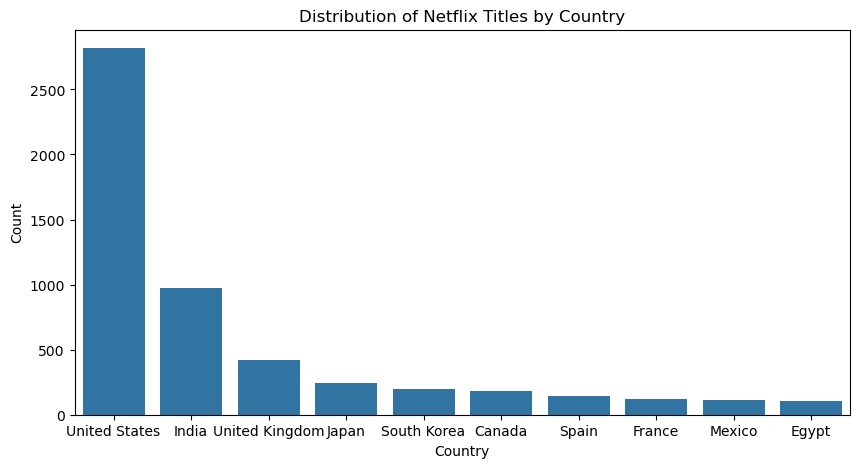

In [121]:
plt.figure(figsize=(10,5))
sns.countplot(data=df_copy, x='country', 
              order=df_copy['country'].value_counts().head(10).index)
plt.title('Distribution of Netflix Titles by Country')
plt.xlabel('Country')
plt.ylabel('Count')

### Observations:
1. Majority of Netflix titles are coming from United States and India
2. The remaining countries contribute comparatively fewer titles, reflecting a long-tail distribution.

In [122]:
df_copy['listed_in'].value_counts().head(10)

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            220
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Name: count, dtype: int64

8. Date Analysis
The date_added column is converted into datetime format to extract year, month, and day for trend analysis.

In [123]:
#Data analysis datetime
df_copy['date_added'].dtype


dtype('O')

In [124]:
df_copy['date_added']=pd.to_datetime(
    df_copy['date_added'].str.strip(),
    errors='coerce'
)

In [125]:
df_copy['date_added'].dtype

dtype('<M8[ns]')

In [126]:
df_copy['year_added']=df_copy['date_added'].dt.year
df_copy['month_added']=df_copy['date_added'].dt.month_name()
df_copy['day_added']=df_copy['date_added'].dt.day


In [127]:
df_copy[['date_added','year_added', 'month_added', 'day_added']].head(2)

,date_added,year_added,month_added,day_added
0,2021-09-25,2021.0,September,25.0
1,2021-09-24,2021.0,September,24.0


In [128]:
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

month_counts= (df_copy['month_added'].value_counts().reindex(month_order))
month_counts

month_added
January      738
February     563
March        742
April        764
May          632
June         728
July         827
August       755
September    770
October      760
November     705
December     813
Name: count, dtype: int64

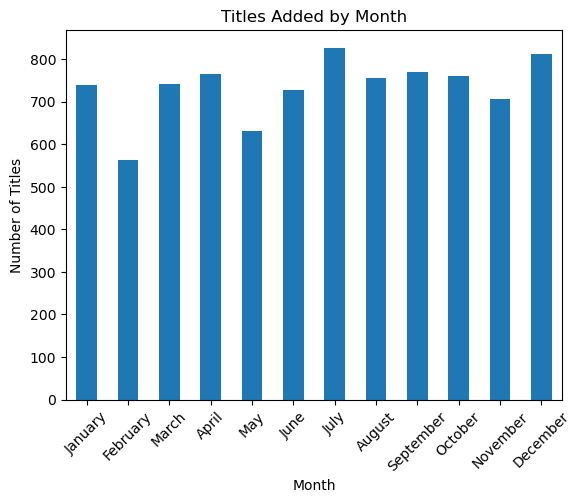

In [129]:
month_counts.plot(kind='bar')
plt.title('Titles Added by Month')
plt.xlabel('Month')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.show()

In [130]:
#Which month had the highest addition?
df_copy['month_added'].value_counts().idxmax()

'July'

In [131]:
df_copy[(df_copy['year_added']==2021) &
        (df_copy['month_added']=='January')]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,day_added
1366,s1367,Movie,Fatima,Marco Pontecorvo,"Joaquim de Almeida, Goran Visnjic, Stephanie G...","Portugal, United States",2021-01-31,2020,PG-13,113 min,"Dramas, Faith & Spirituality","In 1917 Portugal, visions of the Virgin Mary c...",2021.0,January,31.0
1367,s1368,Movie,Hell Fest,Gregory Plotkin,"Amy Forsyth, Reign Edwards, Bex Taylor-Klaus, ...",United States,2021-01-31,2018,R,89 min,Horror Movies,"A serial killer picks off a group of friends, ...",2021.0,January,31.0
1368,s1369,Movie,Below Zero,Lluís Quílez,"Javier Gutiérrez, Karra Elejalde, Luis Callejo...",Spain,2021-01-29,2021,TV-MA,107 min,"Action & Adventure, International Movies","When a prisoner transfer van is attacked, the ...",2021.0,January,29.0
1369,s1370,Movie,Finding ‘Ohana,Jude Weng,"Kea Peahu, Alex Aiono, Lindsay Watson, Owen Va...",United States,2021-01-29,2021,PG,123 min,"Children & Family Movies, Comedies","In Oʻahu for the summer, two siblings from Bro...",2021.0,January,29.0
1370,s1371,Movie,The Dig,Simon Stone,"Carey Mulligan, Ralph Fiennes, Lily James, Joh...",United Kingdom,2021-01-29,2021,PG-13,113 min,"Dramas, International Movies","On the eve of World War II, a British widow hi...",2021.0,January,29.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8272,s8273,Movie,The Departed,Martin Scorsese,"Leonardo DiCaprio, Matt Damon, Jack Nicholson,...","United States, Hong Kong",2021-01-01,2006,R,151 min,"Dramas, Thrillers",Two rookie Boston cops are sent deep undercove...,2021.0,January,1.0
8320,s8321,Movie,The Girl with the Dragon Tattoo,David Fincher,"Daniel Craig, Rooney Mara, Christopher Plummer...","United States, Sweden, Norway",2021-01-05,2011,R,158 min,"Dramas, Thrillers",When a young computer hacker is tasked with in...,2021.0,January,5.0
8434,s8435,Movie,The Naked Gun: From the Files of Police Squad!,David Zucker,"Leslie Nielsen, Priscilla Presley, George Kenn...",United States,2021-01-01,1988,PG-13,85 min,"Comedies, Cult Movies",Hapless cop Frank Drebin causes more problems ...,2021.0,January,1.0
8437,s8438,TV Show,The Netflix Afterparty,NaN,"David Spade, London Hughes, Fortune Feimster",United States,2021-01-02,2021,TV-MA,1 Season,"Stand-Up Comedy & Talk Shows, TV Comedies","Hosts David Spade, Fortune Feimster and London...",2021.0,January,2.0


In [132]:
# How many titles were added to netflix each year?
df_copy['year_added'].value_counts().sort_index()

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
Name: count, dtype: int64

In [133]:
(df_copy['year_added'].value_counts(normalize=True).sort_index() * 100).round(2)

year_added
2008.0     0.02
2009.0     0.02
2010.0     0.01
2011.0     0.15
2012.0     0.03
2013.0     0.13
2014.0     0.27
2015.0     0.93
2016.0     4.88
2017.0    13.50
2018.0    18.75
2019.0    22.92
2020.0    21.36
2021.0    17.03
Name: proportion, dtype: float64

In [134]:
df_copy['year_added'].value_counts().idxmax()

np.float64(2019.0)

In [135]:
df_copy['year_added'].value_counts().max()

2016

In [136]:
df_copy['year_added'].describe()

count    8797.000000
mean     2018.871888
std         1.574243
min      2008.000000
25%      2018.000000
50%      2019.000000
75%      2020.000000
max      2021.000000
Name: year_added, dtype: float64

In [137]:
print("Earliest Year:", df_copy['year_added'].min())
print("Latest Year:", df_copy['year_added'].max())

Earliest Year: 2008.0
Latest Year: 2021.0


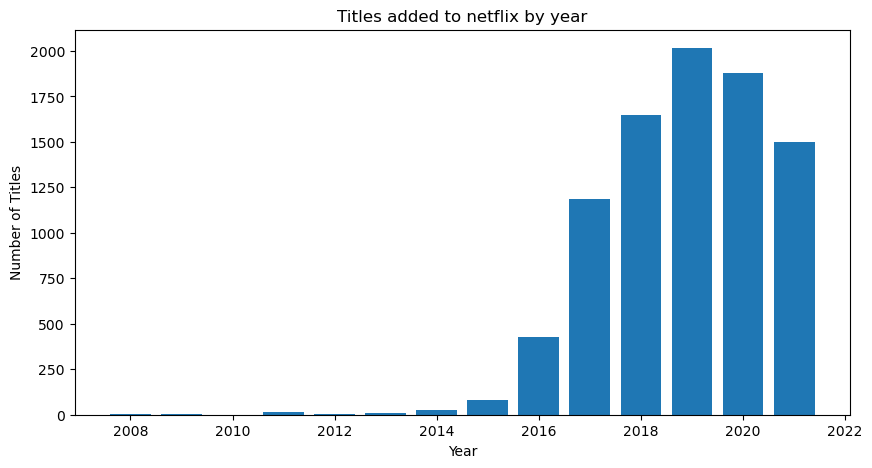

In [138]:
years_counts=df_copy['year_added'].value_counts().sort_index()
plt.figure(figsize=(10,5))
plt.bar(years_counts.index, years_counts.values)
plt.title('Titles added to netflix by year')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.show()

### Observations
1. The highest number of titles were added in 2019. 

In [139]:
df_copy['day_added'].value_counts().sort_index()

day_added
1.0     2212
2.0      325
3.0      151
4.0      175
5.0      231
6.0      210
7.0      194
8.0      201
9.0      147
10.0     214
11.0     149
12.0     181
13.0     175
14.0     198
15.0     687
16.0     289
17.0     180
18.0     207
19.0     243
20.0     249
21.0     193
22.0     230
23.0     184
24.0     159
25.0     197
26.0     206
27.0     195
28.0     190
29.0     141
30.0     210
31.0     274
Name: count, dtype: int64

In [140]:
df_copy['day_added'].describe()

count    8797.000000
mean       12.497329
std         9.887551
min         1.000000
25%         1.000000
50%        13.000000
75%        20.000000
max        31.000000
Name: day_added, dtype: float64

Text(0, 0.5, 'Number of titles')

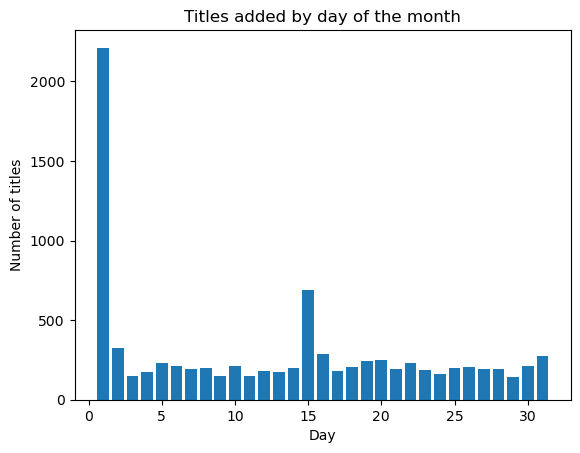

In [141]:
day_counts = df_copy['day_added'].value_counts().sort_index()
plt.bar(day_counts.index, day_counts.values)
plt.title('Titles added by day of the month')
plt.xlabel('Day')
plt.ylabel('Number of titles')

In [142]:
year_month = pd.crosstab(
    df_copy['year_added'],
    df_copy['month_added']
)
year_month

month_added,April,August,December,February,January,July,June,March,May,November,October,September
year_added,,,,,,,,,,,,
2008.0,0,0,0,1,1,0,0,0,0,0,0,0
2009.0,0,0,0,0,0,0,0,0,1,1,0,0
2010.0,0,0,0,0,0,0,0,0,0,1,0,0
2011.0,0,0,0,0,0,0,0,0,1,0,11,1
2012.0,0,0,1,1,0,0,0,0,0,1,0,0
2013.0,0,1,2,0,0,0,0,1,0,2,3,2
2014.0,2,1,6,2,2,1,1,0,0,4,4,1
2015.0,5,2,21,4,1,7,6,5,6,4,14,7
2016.0,22,34,96,15,43,28,18,17,13,44,51,48


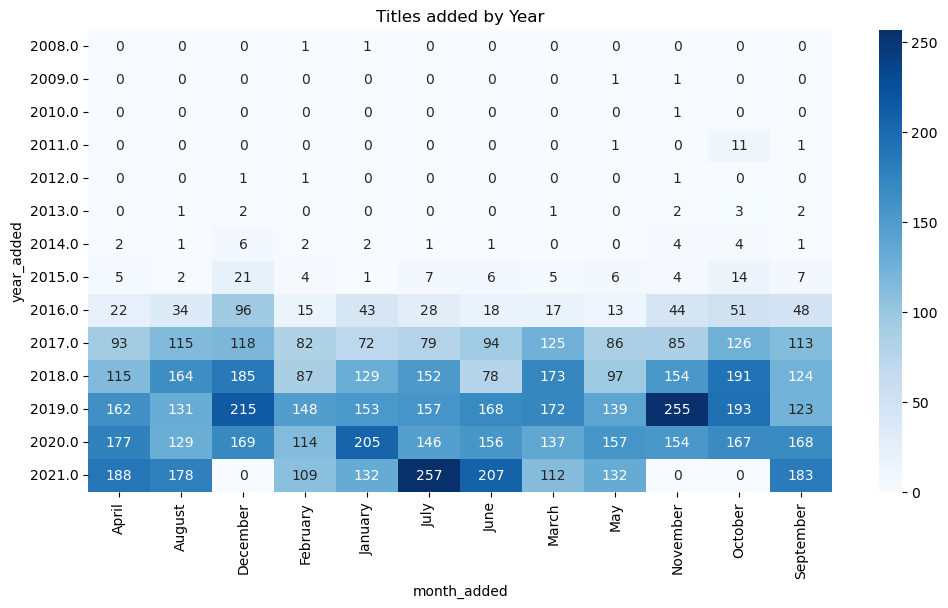

In [143]:
plt.figure(figsize=(12,6))
sns.heatmap(year_month, annot=True, fmt='d', cmap='Blues')
plt.title('Titles added by Year')
plt.show()

9. Bivariate Analysis

Bivariate analysis examines the relationship between two variables to identify patterns and trends.

a. Type vs Rating

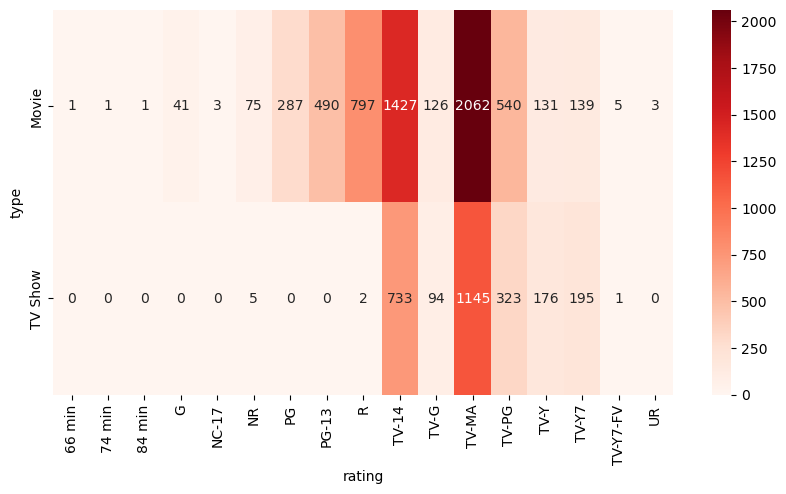

In [144]:
#What ratings are most common for Movies and TV Shows

rating_type=pd.crosstab(
    df_copy['type'],
    df_copy['rating']
)

plt.figure(figsize=(10,5))

sns.heatmap(
    rating_type, annot=True, fmt='d', cmap='Reds'
)

plt.show()


b.  type vs year_added

In [145]:

#how many TV shows or Movies were added each year?

type_year= pd.crosstab(
    df_copy['year_added'],
    df_copy['type']
)
type_year

type,Movie,TV Show
year_added,,
2008.0,1,1
2009.0,2,0
2010.0,1,0
2011.0,13,0
2012.0,3,0
2013.0,6,5
2014.0,19,5
2015.0,56,26
2016.0,253,176


Text(0, 0.5, 'Number of Titles')

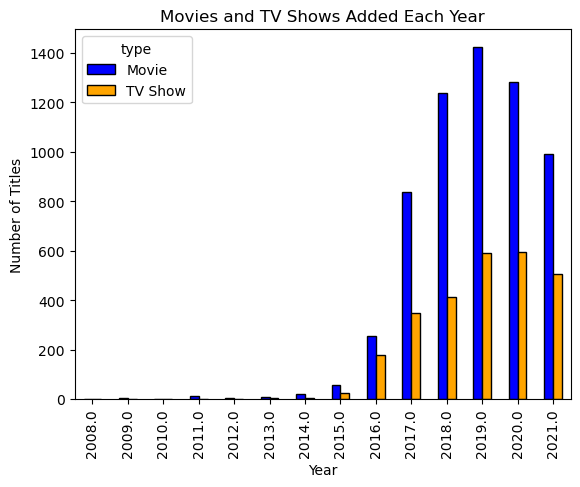

In [146]:
type_year.plot(kind='bar', color=['Blue', 'Orange'], edgecolor='black')
plt.title('Movies and TV Shows Added Each Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles')


c. country vs type

In [147]:

#Which country contributes the most movies and TV Shows
country_type=pd.crosstab(
    df_copy['country'],
    df_copy['type']
)
country_type.sort_values(
    by='Movie',
    ascending=False
).head(10)

type,Movie,TV Show
country,,
United States,2058,760
India,893,79
United Kingdom,206,213
Canada,122,59
Spain,97,48
Egypt,92,14
Nigeria,86,9
Indonesia,77,2
Japan,76,169


d. release year vs type

In [148]:
#How has the number of Movies and TV Shows changed over the years they were released?

release_type=pd.crosstab(
    df_copy['release_year'],
    df_copy['type']
)
release_type.tail(15)

type,Movie,TV Show
release_year,,
2007,74,14
2008,113,23
2009,118,34
2010,154,40
2011,145,40
2012,173,64
2013,225,63
2014,264,88
2015,398,162


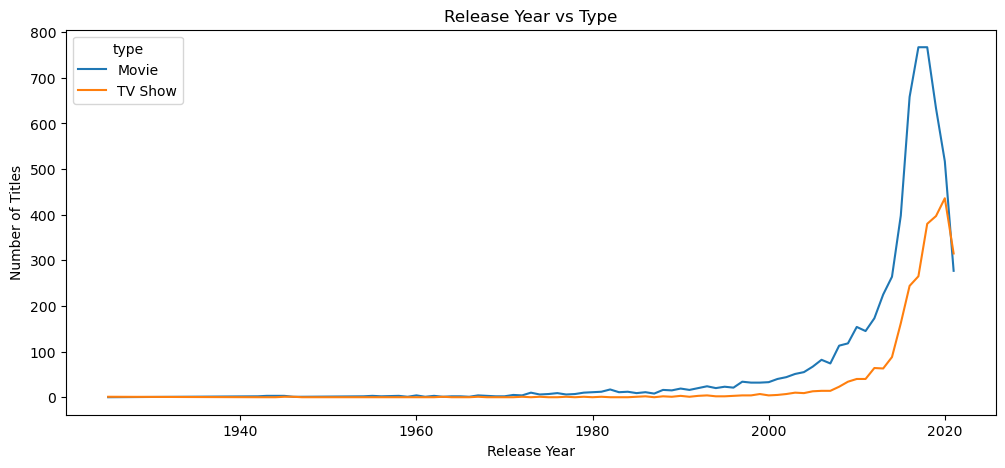

In [149]:
release_type.plot(
    figsize=(12,5)
)

plt.title("Release Year vs Type")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

10. Feature Engineering and Advanced EDA


The duration column contains two different types of information.

Movies → Minutes

TV Shows → Seasons

To perform numerical analysis, separate features are created.

In [150]:
df_copy['duration'].head()

0       90 min
1    2 Seasons
2     1 Season
3     1 Season
4    2 Seasons
Name: duration, dtype: object

In [151]:
df_copy['duration'].value_counts().head()

duration
1 Season     1793
2 Seasons     425
3 Seasons     199
90 min        152
94 min        146
Name: count, dtype: int64

In [152]:
#separate movie and tv shows
movies = df_copy[df_copy['type'] == 'Movie']
movies.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,day_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,September,25.0
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,2021.0,September,24.0
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",2021.0,September,24.0
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,2021.0,September,24.0
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021-09-23,2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...,2021.0,September,23.0


In [153]:
tv_shows=df_copy[df_copy['type'] == 'TV Show']
df_copy.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,day_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,September,25.0
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,September,24.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,September,24.0
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,September,24.0
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,September,24.0


In [154]:
movies['duration_min'] = pd.to_numeric(
    movies['duration'].str.replace(' min', '', regex=False),
    errors='coerce'
)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_36020\3042212989.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies['duration_min'] = pd.to_numeric(


In [155]:
movies['duration_min']=movies['duration_min'].fillna(movies['duration_min'].mean())

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_36020\1560326166.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies['duration_min']=movies['duration_min'].fillna(movies['duration_min'].mean())


In [156]:
#Longest Movie
movies.loc[movies['duration_min'].idxmax(), ['title', 'duration_min']]

title           Black Mirror: Bandersnatch
duration_min                         312.0
Name: 4253, dtype: object

In [157]:
#Shortest Movie
movies.loc[movies['duration_min'].idxmin(), ['title', 'duration_min']]

title           Silent
duration_min       3.0
Name: 3777, dtype: object

In [158]:
movies['duration_min'].describe()

count    6131.000000
mean       99.577187
std        28.283670
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_min, dtype: float64

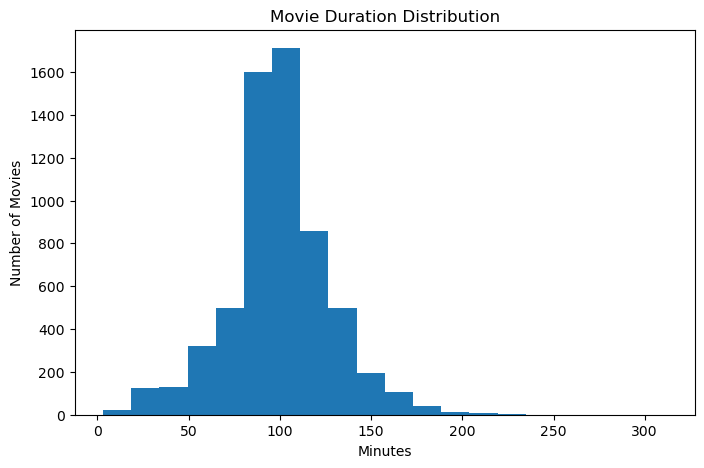

In [159]:
plt.figure(figsize=(8,5))

plt.hist(movies['duration_min'], bins=20)

plt.title("Movie Duration Distribution")
plt.xlabel("Minutes")
plt.ylabel("Number of Movies")

plt.show()

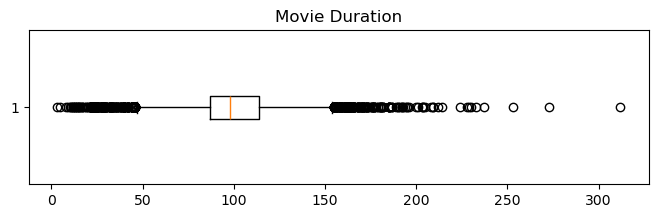

In [160]:
plt.figure(figsize=(8,2))

plt.boxplot(movies['duration_min'], vert=False)
plt.title("Movie Duration")
plt.show()

In [161]:
tv_shows['seasons'] = (
    tv_shows['duration']
    .str.extract('(\d+)')
    .astype(int)
)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_36020\3425724346.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tv_shows['seasons'] = (


In [162]:
tv_shows['seasons'].mean()

np.float64(1.764947683109118)

In [163]:
tv_shows.loc[tv_shows['seasons'].idxmax(), ['title', 'seasons']]

title      Grey's Anatomy
seasons                17
Name: 548, dtype: object

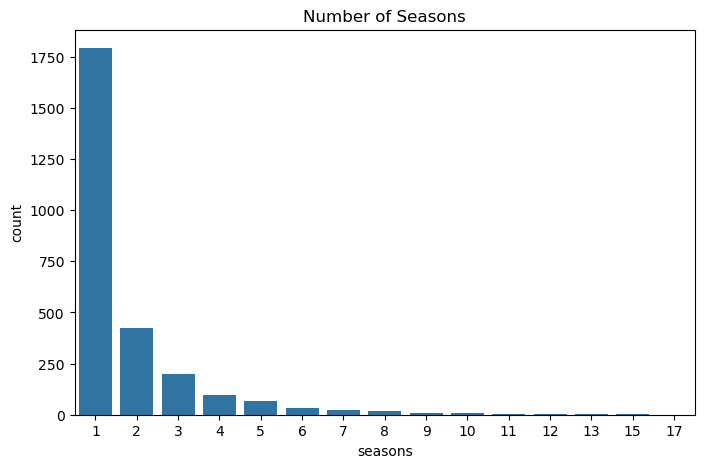

In [164]:
plt.figure(figsize=(8,5))

sns.countplot(data=tv_shows, x='seasons')

plt.title("Number of Seasons")

plt.show()

#### Business Insights

1.Movies dominate Netflix's catalog.

2.Netflix rapidly expanded its content library after 2016.

3.TV-MA is the most common content rating.

4.The United States contributes the largest amount of content.

5.Most movies are between 90 and 120 minutes long.

6.Most TV Shows have only one or two seasons.

#### Conclusion

This project demonstrated the complete EDA workflow using Python, Pandas, Matplotlib, and Seaborn.

The dataset was cleaned, transformed, analyzed, and visualized to identify trends in Netflix's content library.

The project showcases practical data cleaning, feature engineering, exploratory analysis, and business insight generation skills.